# Design a mode-based imager system

Recall from [Intro](./0_intro_to_mode_based_imaging.ipynb) that we measure diagonal components of $U \left[ \int \Gamma \cdot \mathbf{K} \right] U^\dagger$. By designing the $U$ matrix, we can optimize observables.

One way of designing $U$ is through the design of the photonic lantern itself. The lantern's transfer matrix depends on the lantern's waveguide geometry. Another way is to introduce interference between lantern outputs, which can be done through a photonic integrated circuit (PIC).

This notebook shows how the lantern observables change with the choice of the lantern transfer matrix, and illustrates how to design PIC in the `PLsim` framework.

In [1]:
from PLsim.otf import OTF
from PLsim.scene import Scene, SceneProjector
from PLsim.system.device import Device

import hcipy as hc
import numpy as np
import matplotlib.pyplot as plt

Set up grids and OTFs

In [2]:
# Define pupil grid
ndim = 65 # this is enough for a 6-port PL
diameter = 10 # meters
pupil_grid = hc.make_pupil_grid(ndim, diameter)
ref_wavelength = 1.55e-6 # meters

# Define focal grid 
focal_plane_resolution = 1e-6 # meters. Make sure this samples LP modes enough but also not truncate the outer parts.
focal_length = 40 # meters (just an initial value. OTF.from_fiber_params will find an optimal focal ratio)
focal_grid = hc.make_pupil_grid(ndim, focal_plane_resolution * ndim)

# Define PL multimode entrance parameters (changing this would change the number of guided modes)
ncore = 1.444
nclad = 1.444 - 5.5e-3
rcore = 6e-6 # meters

# Telescope aperture (circular)
aperture = hc.make_circular_aperture(diameter)(pupil_grid)

In [4]:
otf = OTF.from_fiber_params(ncore, nclad, rcore, ref_wavelength,
                            focal_grid, pupil_grid, focal_length,
                            aperture, optimize_focal_length = False)
otf.compute()

Supported modes:  ['LP01', 'LP11a', 'LP11b']
Number of modes:  3


Set up mode sorting device

In [14]:
from PLsim.system.lantern import generate_unitary_matrix

nwav = 1
matrix_MSPL  = np.eye(3)[np.newaxis,:,:].repeat(nwav, axis=0)
matrix_SPL  = generate_unitary_matrix(3)[np.newaxis,:,:].repeat(nwav, axis=0)

In [15]:
from PLsim.system.device import Device
device_MSPL = Device(matrix_MSPL)
device_SPL = Device(matrix_SPL)

Device initialized with:
  Lantern matrices: (1, 3, 3)
  PIC matrices: None
  Wavelengths: 1
Device initialized with:
  Lantern matrices: (1, 3, 3)
  PIC matrices: None
  Wavelengths: 1


Set up the scene

In [19]:
from PLsim.scene import Scene, SceneProjector
scene = Scene(pupil_grid, ref_wavelength)
scene_projector = SceneProjector(otf, scene)

# Compute the on-axis and off-axis points

point_onaxis = scene_projector.compute_point(0,0)

planet_sep = 30e-3/206265 # 30 mas
planet_contrast = 1e-1 
point_offaxis = scene_projector.compute_point(planet_sep,0) 

Compute output intensities

In [20]:
out_onaxis_MSPL = device_MSPL.calculate_outputs(point_onaxis)
out_offaxis_MSPL = device_MSPL.calculate_outputs(point_offaxis) * planet_contrast
out_onaxis_SPL = device_SPL.calculate_outputs(point_onaxis)
out_offaxis_SPL = device_SPL.calculate_outputs(point_offaxis) * planet_contrast


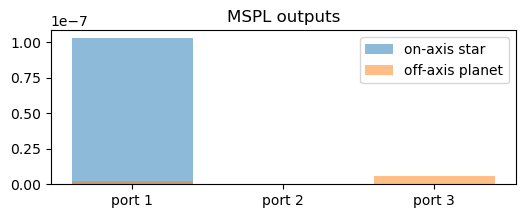

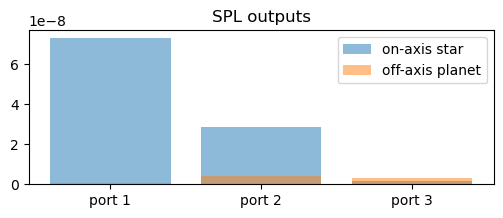

In [24]:
plt.figure(figsize=(6,2))
plt.bar(range(3), out_onaxis_MSPL[0,:,0], alpha=0.5, label='on-axis star')
plt.bar(range(3), out_offaxis_MSPL[0,:,0], alpha=0.5, label='off-axis planet')
plt.xticks(range(3), ['port 1', 'port 2', 'port 3'])
plt.legend()
plt.title('MSPL outputs')
plt.show()

plt.figure(figsize=(6,2))
plt.bar(range(3), out_onaxis_SPL[0,:,0], alpha=0.5, label='on-axis star')
plt.bar(range(3), out_offaxis_SPL[0,:,0], alpha=0.5, label='off-axis planet')
plt.xticks(range(3), ['port 1', 'port 2', 'port 3'])
plt.legend()
plt.title('SPL outputs')
plt.show()

We see that all the starlight couples to port 1 for MSPL (perfect nulling in ports 2 and 3) while for standard PL starlight leaks into other ports. This behavior is determined by the transfer matrix!

We can simulate coupling maps as well.

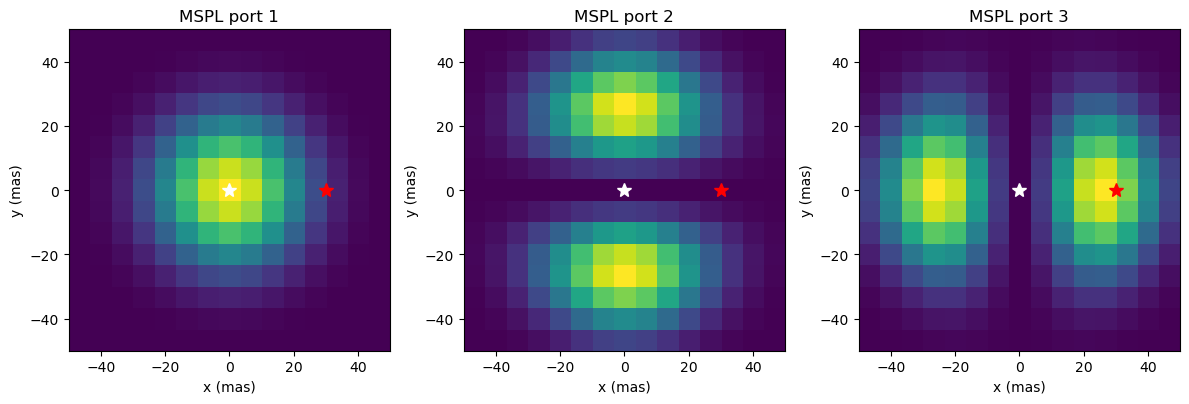

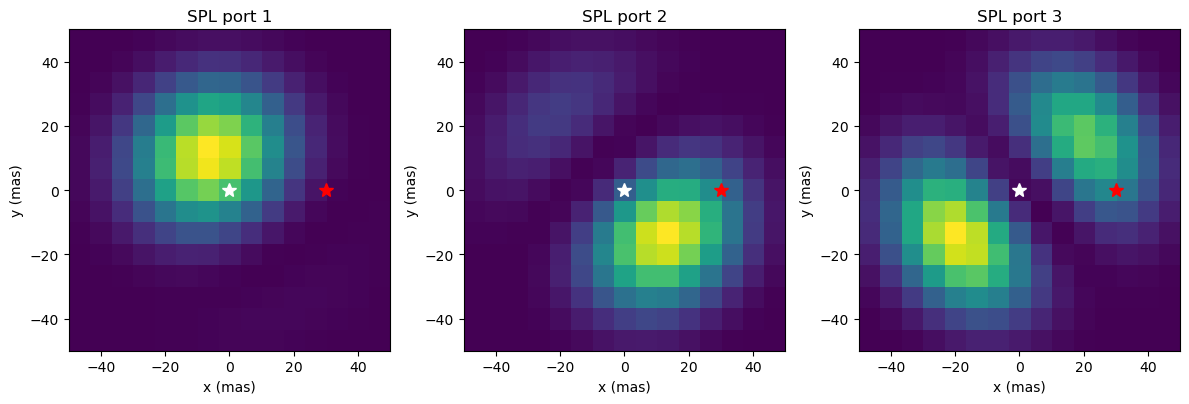

In [87]:
fov = 100e-3/206265
ngrid = 15
out_grid = scene_projector.compute_point_grid(fov, ngrid)

out_MSPL_grid = device_MSPL.calculate_outputs(out_grid)
out_SPL_grid = device_SPL.calculate_outputs(out_grid)

fig, axs = plt.subplots(1,3, figsize=(12,4))
for i in range(3):
    axs[i].imshow(out_MSPL_grid[0,i], extent = (-fov/2 * 206265e3, fov/2 * 206265e3, -fov/2 * 206265e3, fov/2 * 206265e3), origin='lower')
    axs[i].set_title(f'MSPL port {i+1}')
    axs[i].set_xlabel('x (mas)')
    axs[i].set_ylabel('y (mas)')
    axs[i].plot(0,0,'*',color='white',ms=10)
    axs[i].plot(planet_sep*206265e3,0,'*',color='red',ms=10)
fig.tight_layout()
plt.show()

fig, axs = plt.subplots(1,3, figsize=(12,4))
for i in range(3):
    axs[i].imshow(out_SPL_grid[0,i], extent =  (-fov/2 * 206265e3, fov/2 * 206265e3, -fov/2 * 206265e3, fov/2 * 206265e3), origin='lower')
    axs[i].set_title(f'SPL port {i+1}')
    axs[i].set_xlabel('x (mas)')
    axs[i].set_ylabel('y (mas)')
    axs[i].plot(0,0,'*',color='white',ms=10)
    axs[i].plot(planet_sep*206265e3,0,'*',color='red',ms=10)
fig.tight_layout()
plt.show()



### Altering transfer matrix with a PIC

Let's assume we have a 2x2 Mach-Zehnder Interferometer. We will try to clean up the starlight leakage into Port 2 of standard lantern by interfering ports 1 and 2.

This is how to create a 2x2 MZI!

In [ ]:
# define 2x2 MZI

import PLsim.system.pic as pic

# active device template
def create_active_mzi(phase_shift1=0, phase_shift2=0):
    # """Template function for the MZI device with adjustable phase shifts."""
    
    # define the input names: I'll say a and b
    device = pic.PIC(['a', 'b'], name="Active MZI")

    # add phase shift in front of the "a"
    ps1 = pic.PhaseShifter('ps1', ['a'], ['a'], phase_shift=phase_shift1)
    device.add_component(ps1)

    # add MZI
    mzi = pic.MZI('mzi1', ['a', 'b'], ['a', 'b'], phase_shift=phase_shift2)
    device.add_component(mzi)

    return device

# Create active MZI
active_mzi = pic.ActivePIC(
    device_template=create_active_mzi,
    parameter_names=['phase_shift1', 'phase_shift2'],
    initial_parameters={'phase_shift1': 0, 'phase_shift2': 0},
    name="Active MZI"
)

Define the device, PL + PIC

In [89]:
device_pic = Device(matrix_SPL, pic_device=active_mzi, port_mapping=[(0,0), (1,1)],
                    verbose =False)
# port mapping (0,0), (1,1) means port 1 of SPL goes into port 1 of MZI, port 2 of SPL goes into port 2 of MZI.

Set the phase shifter values (play around with different phase shifter values)

In [90]:
device_pic.update_pic_matrix(phase_shift1=np.pi*0.5, phase_shift2=np.pi*0.3)


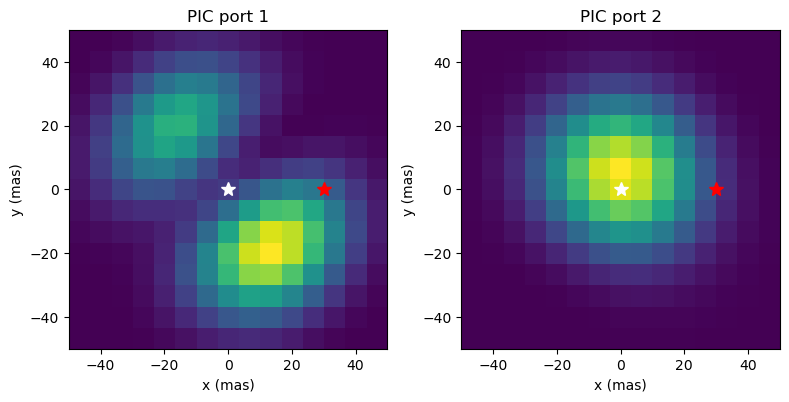

In [91]:

out_PIC_grid = device_pic.calculate_outputs(out_grid)

fig, axs = plt.subplots(1,2, figsize=(8,4))
for i in range(2):
    axs[i].imshow(out_PIC_grid[0,i], extent = (-fov/2 * 206265e3, fov/2 * 206265e3, -fov/2 * 206265e3, fov/2 * 206265e3), origin='lower')
    axs[i].set_title(f'PIC port {i+1}')
    axs[i].set_xlabel('x (mas)')
    axs[i].set_ylabel('y (mas)')
    axs[i].plot(0,0,'*',color='white',ms=10)
    axs[i].plot(planet_sep*206265e3,0,'*',color='red',ms=10)
fig.tight_layout()
plt.show()


In [92]:
out_onaxis_PIC = device_pic.calculate_outputs(point_onaxis)
out_offaxis_PIC = device_pic.calculate_outputs(point_offaxis) * planet_contrast

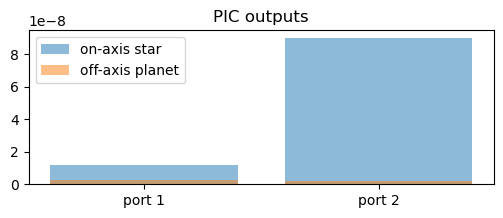

In [93]:
plt.figure(figsize=(6,2))
plt.bar(range(2), out_onaxis_PIC[0,:,0], alpha=0.5, label='on-axis star')
plt.bar(range(2), out_offaxis_PIC[0,:,0], alpha=0.5, label='off-axis planet')
plt.xticks(range(2), ['port 1', 'port 2'])
plt.legend()
plt.title('PIC outputs')
plt.show()

In [94]:
from scipy.optimize import minimize

def fmin(params):
    device_pic.update_pic_matrix(phase_shift1=params[0], phase_shift2=params[1])
    out_onaxis = device_pic.calculate_outputs(point_onaxis)
    return out_onaxis[0,1,0]/out_onaxis[0,0,0]

In [95]:
opt = minimize(fmin, [0,np.pi/2], bounds=[(0, 2*np.pi), (0, 2*np.pi)])
opt

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 4.089135893980887e-13
        x: [ 7.855e-01  4.257e+00]
      nit: 11
      jac: [-3.890e-08  6.403e-07]
     nfev: 36
     njev: 12
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

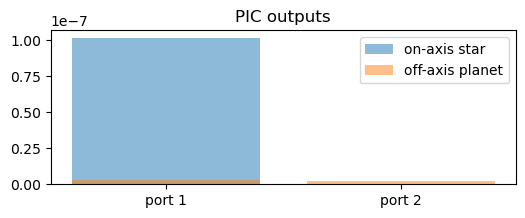

In [96]:
device_pic.update_pic_matrix(phase_shift1=opt.x[0], phase_shift2=opt.x[1])
out_onaxis_PIC = device_pic.calculate_outputs(point_onaxis)
out_offaxis_PIC = device_pic.calculate_outputs(point_offaxis) * planet_contrast

plt.figure(figsize=(6,2))
plt.bar(range(2), out_onaxis_PIC[0,:,0], alpha=0.5, label='on-axis star')
plt.bar(range(2), out_offaxis_PIC[0,:,0], alpha=0.5, label='off-axis planet')
plt.xticks(range(2), ['port 1', 'port 2'])
plt.legend()
plt.title('PIC outputs')
plt.show()

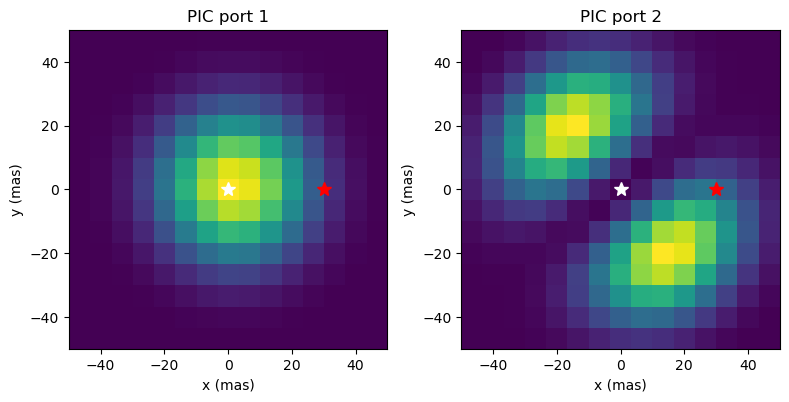

In [102]:

out_PIC_grid = device_pic.calculate_outputs(out_grid)

fig, axs = plt.subplots(1,2, figsize=(8,4))
for i in range(2):
    axs[i].imshow(out_PIC_grid[0,i], extent = (-fov/2 * 206265e3, fov/2 * 206265e3, -fov/2 * 206265e3, fov/2 * 206265e3), origin='lower',
                  )
    axs[i].set_title(f'PIC port {i+1}')
    axs[i].set_xlabel('x (mas)')
    axs[i].set_ylabel('y (mas)')
    axs[i].plot(0,0,'*',color='white',ms=10)
    axs[i].plot(planet_sep*206265e3,0,'*',color='red',ms=10)
fig.tight_layout()
plt.show()


We have a nice null!

Of course we need a more complicated setup if we want to actually minimize starlight and maximize planet light in one port.